#Librerias

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

#Datos

Primero importamos los datos subiendo el csv al archivo del colab

In [ ]:
datos = pd.read_csv("auto-mpg.csv")

## Exploración y limpieza de datos

A partir de la informacion en este DataFrame, se busca identificar las variables importantes. En un primer acercamiento de inspeccion básica se ve

In [ ]:
print(datos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None


De esto podemos ver que tenemos 9 columnas de datos con 398 valores no nulos. Al mismo tiempo que identificamos que tipo de variables contiene cada una de estas.

In [ ]:
print(datos.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


De los valores proporcionados, no se aprecian la existencia de valores nulos. Ahora buscamos ver los primeros y ultimos valores de las columnas

In [ ]:
print(datos.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [ ]:
print(datos.tail())

      mpg  cylinders  displacement horsepower  weight  acceleration  \
393  27.0          4         140.0         86    2790          15.6   
394  44.0          4          97.0         52    2130          24.6   
395  32.0          4         135.0         84    2295          11.6   
396  28.0          4         120.0         79    2625          18.6   
397  31.0          4         119.0         82    2720          19.4   

     model year  origin         car name  
393          82       1  ford mustang gl  
394          82       2        vw pickup  
395          82       1    dodge rampage  
396          82       1      ford ranger  
397          82       1       chevy s-10  


Se ve que la columna *origin* contiene valores numericos que no hacen referencia a ningun lugar geografico ni año (ya tenemos la columna *model year* para referirse al año). Por tanto, se opta por eliminar de los datos de interes dicha columna al considerarse una columna con valores faltantes.

In [ ]:
datos_filtrados_1 = datos.drop(columns=['origin'])
datos = datos_filtrados_1

Por otra parte, podemos ver cuales son numericas y cuales no.

In [ ]:
numeric_cols = datos.select_dtypes(include=['number']).columns
non_numeric_cols = datos.select_dtypes(exclude=['number']).columns


In [ ]:
print("Los numericos: ", numeric_cols)
print("Los no numericos: ", non_numeric_cols)

Los numericos:  Index(['mpg', 'cylinders', 'displacement', 'weight', 'acceleration',
       'model year'],
      dtype='object')
Los no numericos:  Index(['horsepower', 'car name'], dtype='object')


Donde nos damos cuenta que la columna *horsepower* está escrita como un string. Este formato no es util para los algoritmos de analisis, y por tanto queremos transformarlo en uno que si. Por ejemplo uno numerico (float).

Ejecutando el codigo nos damos cuenta que esta columna contiene valores no numericos que no podemos transformar. Ubicándolos usando los índices de los valores no numéricos,

In [ ]:
numeric_values = pd.to_numeric(datos['horsepower'], errors='coerce')
non_numeric_indices = np.where(np.isnan(numeric_values))[0]

# Obtener los valores no numéricos en la columna original
non_numeric_values = datos['horsepower'].iloc[non_numeric_indices]

print("Valores no numéricos en la columna 'horsepower' " , non_numeric_values)

Valores no numéricos en la columna 'horsepower'  32     ?
126    ?
330    ?
336    ?
354    ?
374    ?
Name: horsepower, dtype: object


Al desconocer estos valores de *horse power*, se tiene que tener cuidado de usar los otros valores de las variables asociadas en las respectivas filas. No puedo reemplazar estos valores no numericos con 0, debido a que sesgarian mi muestra. Por otra parte, opino que al tener tantos valores muestrales, es seguro eliminar estas filas antes de extrapolar un valor de *horsepower* medio. Es decir que mi poblacion total seria 398 - 6 = 392.

Puedo filtrar entonces las filas y al mismo tiempo convertir el resto de la columna en numericos.

In [ ]:
datos['horsepower'] = pd.to_numeric(datos['horsepower'], errors='coerce')

# Filtrar las filas donde 'horsepower_numeric' es NaN (valores no numéricos)
datos_filtrados_2 = datos[datos['horsepower'].notna()]
datos = datos_filtrados_2


In [ ]:
#Misma prueba para ver si tiene valores no numericos ahora.
numeric_values = pd.to_numeric(datos['horsepower'], errors='coerce')
non_numeric_indices = np.where(np.isnan(numeric_values))[0]

# Obtener los valores no numéricos en la columna original
non_numeric_values = datos['horsepower'].iloc[non_numeric_indices]

print("Valores no numéricos en la columna 'horsepower' " , non_numeric_values)

Valores no numéricos en la columna 'horsepower'  Series([], Name: horsepower, dtype: float64)


En el cual no vemos ninguno no numerico. Para finalizar, visualicemos las distribuciones de los datos usando


In [ ]:
datos.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


Analizando las distribuciones de estas variables.

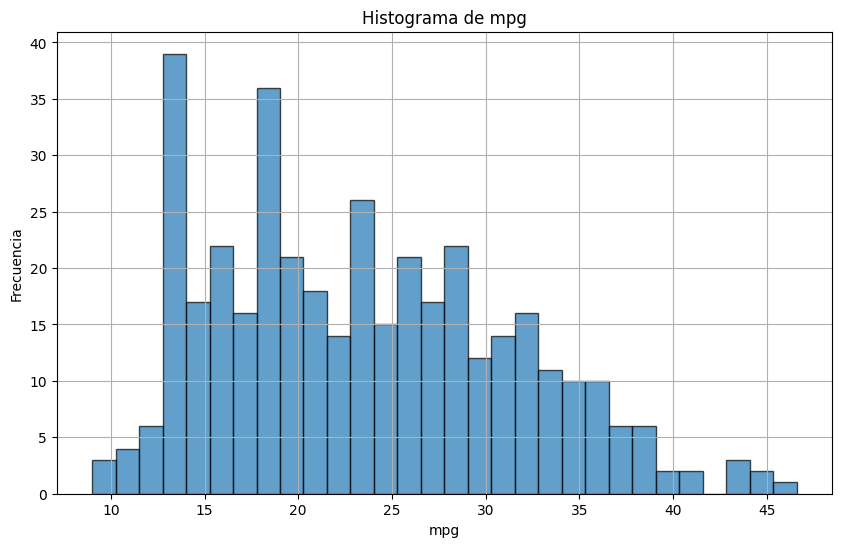

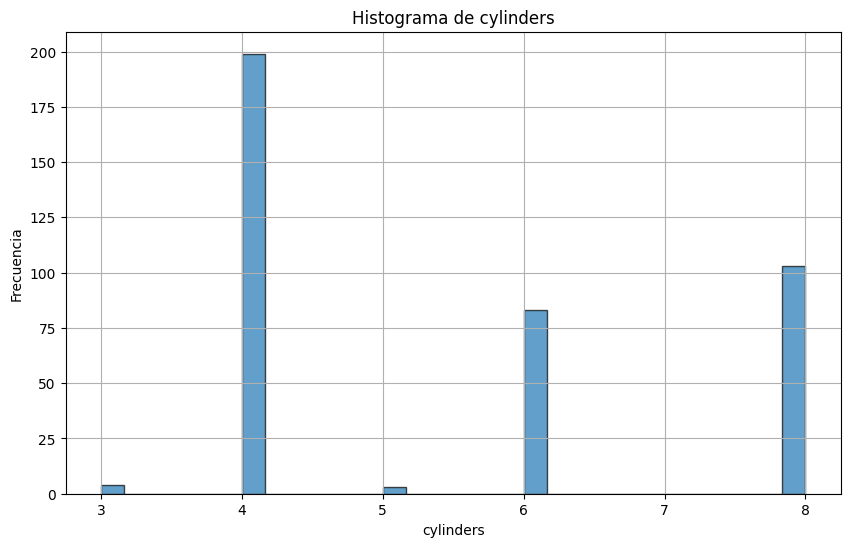

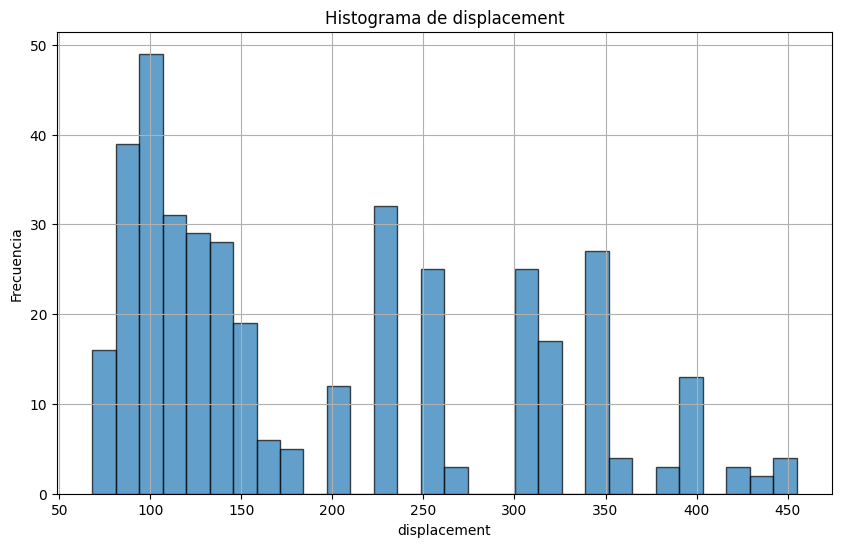

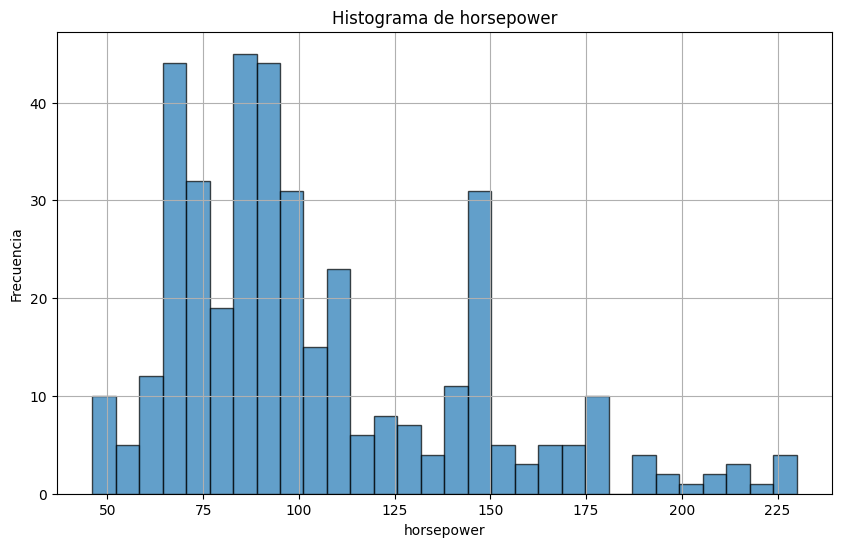

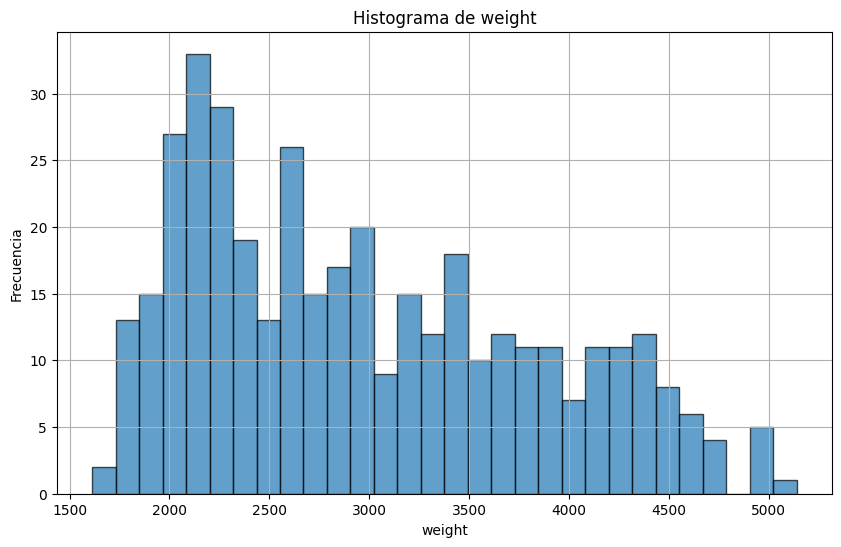

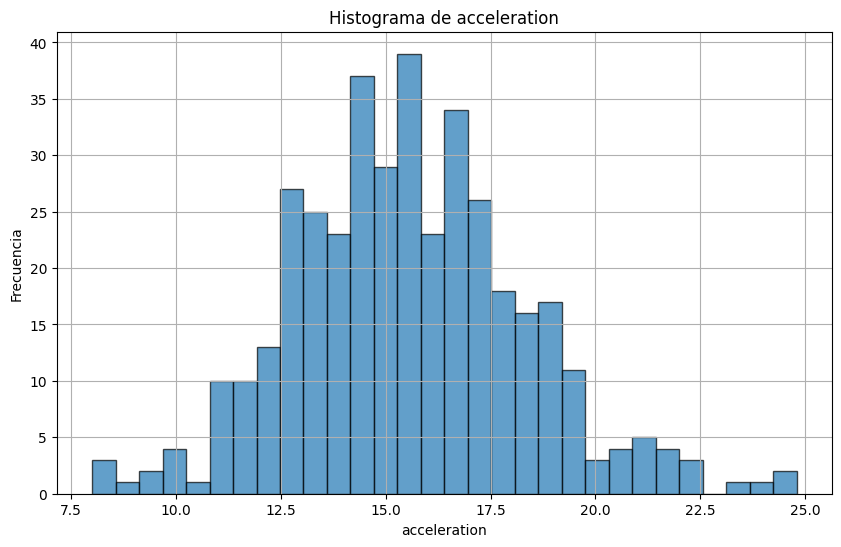

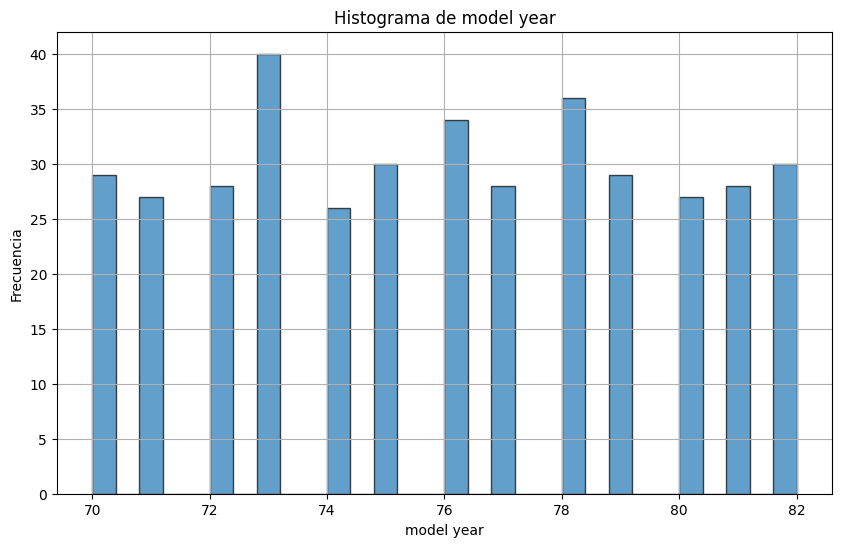

In [ ]:
for columna in datos.columns:
  if columna != 'car name':
    plt.figure(figsize=(10, 6))
    plt.hist(datos[columna].dropna(), bins=30, edgecolor='k', alpha=0.7)
    plt.title(f'Histograma de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()
  else:
    break

Vemos distintos tipos de distribuciones, como puede ser uniformes para la variable de *model year* o simetricas para *acceleration*. A simple vista no se consiguen ver outliers en datos. Pero para establecer un criterio formal, se usa el metodo de IQR para eliminar posibles outliers, dividiendo en quartiles las muestras y sacando aquellas que esten fuera de los limites superiores o inferiores de tolerancia.

In [ ]:
def eliminar_outliers(df):
    df_filtrado = df.copy()
    for columna in df.columns:
      if columna != 'car name':
        # Calcular Q1 (primer cuartil) y Q3 (tercer cuartil)
        Q1 = df[columna].quantile(0.25)
        Q3 = df[columna].quantile(0.75)
        IQR = Q3 - Q1

        # Definir límites inferior y superior
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Filtrar el DataFrame para eliminar los outliers de la columna actual
        df_filtrado = df_filtrado[(df_filtrado[columna] >= limite_inferior) & (df_filtrado[columna] <= limite_superior)]
    return df_filtrado

# Aplicar la función a todas las columnas del DataFrame 'datos'
datos_sin_outliers = eliminar_outliers(datos)
datos = datos_sin_outliers



## Variables de interes (Feature selection)

El problema de interes es conseguir un modelo que me permita predecir al eficiencia energetica de un vehiculo. Para esto, identificamos que las variables de interes puede ser

*mpg* : Significa "Miles per gallon", e indica la cantidad de distancia que puede recorrer el vehiculo por una cantidad de combustible dada.

*cylinders* : Significan la cantidad de cilindros que tiene el motor del vehiculo, a mayor cantidad de cilindros se espera mas potencia. Pero tambien mas consumo, al ser el lugar donde se lleva a cabo la ingicion del combustible.

*displacement* :  Relacionado con la anterior variable, mide el volumen total de todos los cilindros del motor. A mayor medida de este volumen, mas aire y combustible cada piston puede mover.

*horsepower* : Es una medidad de potencia, indica que tan rapido se genera la fuerza del motor.

*weight* : Indica el peso del vehiculo. Sabiendo que se necesita mas fuerza para mover algo de mayor masa, esperamos que este correlacionado con la cantidad de consumicion.

*model year* : Indica el año de manufacturacion del vehiculo. Teniendo en cuenta que las tecnicas de ensamblado mejoran con el tiempo, es de esperar que los vehiculos mas modernos hagan mejor uso de las caracteristicas anteriormente expuestas.

*car name* : Es posible que distintos manufacturadores de autos hagan mejor provecho del combustible.

*acceleration* : Capacidad de ganar velocidad en un intervalo de tiempo.


Identificando la variable target *mpg* como aquella que me dará que tan eficiente es un vehiculo en el consumo de combustible. Se busca entonces poder elegir un subconjunto de las otra variables que me permitan ver en que casos tengo mayor *mpg* dadas las otras caracteristicas.  


Aplicando Feature encoding para mi unica variable categorica (*car name*)

In [ ]:
datos['car name'].value_counts()
datos['car name_codes'] = datos['car name'].astype('category').cat.codes
datos.drop(columns='car name',inplace=True)

Podemos ahora buscar las correlaciones entre todas mis variables numericas y la categorica codificada.

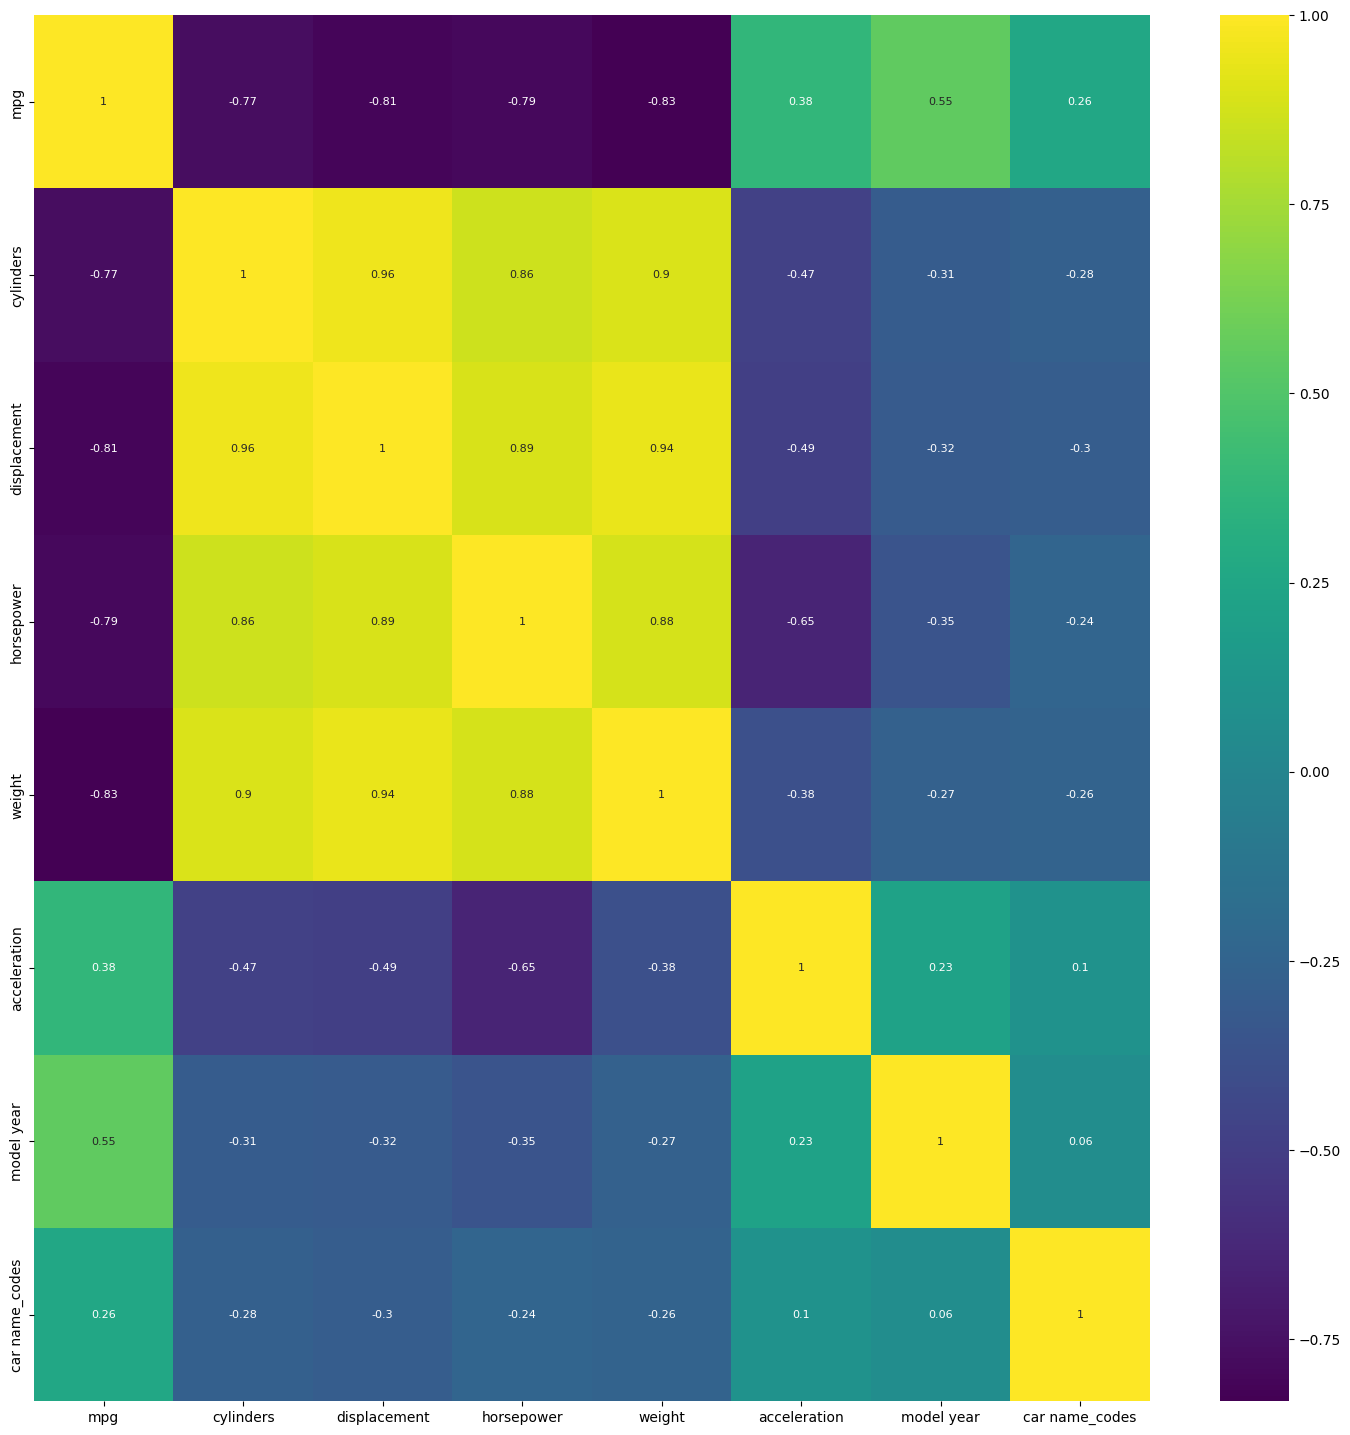

In [ ]:
# Calcula la correlación de Pearson
correlacion_pearson = datos.corr(method='pearson')
plt.figure(figsize=(18,18))
sns.heatmap(correlacion_pearson , annot=True, cmap="viridis",annot_kws={"size":8})
plt.show()

Donde se ve una fuerte correlacion positiva entre las variables *cylinders* , *displacement* , *horsepower* y *weight*. De forma que las variaciones de una de estas cantidades, esta fuertemente relacionada a las variaciones de las otras.

Para poder seleccionar la variables de interés, utilizaremos el modelo de Lasso, debido a que el modelo de correlaciones, al tener valores tan alto, incluye todas las variables de los datos.

In [ ]:
X = datos.drop(columns=['mpg'])  #El target es mpg
Y = datos['mpg']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Escalar las características para mejorar el rendimiento del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo de regresión Lasso
lasso = Lasso(alpha=0.2)
lasso.fit(X_train_scaled, y_train)

# Evaluar el modelo
y_pred = lasso.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Obtener las características seleccionadas por el modelo Lasso
selected_features = [feature for feature, coef in zip(X.columns, lasso.coef_) if coef != 0]
print("Selected Features:", selected_features)

Mean Squared Error: 10.865975365989845
Selected Features: ['horsepower', 'weight', 'model year', 'car name_codes']


Finalmente, se redujo el modelo a 4 variables predictivas que van a ser las que utilice el modelo para ajustar la variable target *mpg*.

## Implementación del modelo

Como el objetivo es que este modelo de aprendizaje automático sea capaz de predecir la eficiencia energética de un vehículo en base a sus características técnicas. Se utilizará un modelo supervisado que me permita modelar una relacion entre las variable independientes o predictivas (las elegidas en feature selection) y la variable dependiente o target *mpg*.

De esta forma, puedo usar el modelo de regresion lineal porque se observa una correlacion entre las variables predictivas y la target. Y ya eliminamos las variables predictivas redundantes usando el test de Lasso (evitando la multicoliealidad).

Al mismo tiempo, usaremos el modelo polinómico para ver cual genera mejores metricas de evaluacion. Se utilizaran como medias de los modelos los coeficientes $R^2$ y $RMSE$.

In [ ]:
X = datos[['horsepower', 'weight', 'model year', 'car name_codes']] #Predictivas
y = datos['mpg'] #target

#Dividir los datos en conjunto de entrenamiento y conjunto de prueba (80-20)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Dividir el conjunto de entrenamiento en conjunto de entrenamiento y conjunto de validación (75-25)
X_train, X_val, y_train, y_val = train_test_split(X_train_temp, y_train_temp, test_size=0.25, random_state=42)

Divimos los datos en tres secciones. Primero la de entrenamiento 80% y prueba 20% de los totales.

Luego tomamos el 25% de los de entrenamiento para una primera instancia de validacion del modelo, previo a los valores de prueba.

###Modelo lineal

In [ ]:
regressor= LinearRegression() #Modelo de regresion lineal
regressor.fit(X_train, y_train)

y_pred_train = regressor.predict(X_train)
y_pred_val = regressor.predict(X_val)
y_pred_test = regressor.predict(X_test)

# Calcula el error cuadrático medio (MSE) en el conjunto de entrenamiento y prueba
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
mse_val = mean_squared_error(y_val, y_pred_val)

rmse_train = np.sqrt(mse_train) #El RMSE tomando la raíz cuadrada del MSE
rmse_test = np.sqrt(mse_test)
rmse_val = np.sqrt(mse_val)

# Calcula el coeficiente de determinación (R^2) en el conjunto de entrenamiento y prueba
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
r2_val = r2_score(y_val, y_pred_val)


print("R^2 en conjunto de entrenamiento:", r2_train)
print("R^2 en conjunto de prueba:", r2_test)
print("R^2 en conjunto de validacion:", r2_val)
print(" ")
print("RMSE en conjunto de entrenamiento:", rmse_train)
print("RMSE en conjunto de prueba:", rmse_test)
print("RMSE en conjunto de validacion:", rmse_val)

R^2 en conjunto de entrenamiento: 0.8131815648236913
R^2 en conjunto de prueba: 0.8281522675893065
R^2 en conjunto de validacion: 0.7849535289693098
 
RMSE en conjunto de entrenamiento: 3.259759132739235
RMSE en conjunto de prueba: 3.3022516011164327
RMSE en conjunto de validacion: 3.4685951547908966


###Modelo polinomico de grado 2

In [ ]:
poly_regs = PolynomialFeatures(degree=2)
X_poly_train = poly_regs.fit_transform(X_train)
X_poly_test = poly_regs.transform(X_test)
X_poly_val = poly_regs.transform(X_val)

#Ajustar el modelo de regresión polinómica
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_test = lin_reg_2.predict(X_poly_test)
y_pred_train = lin_reg_2.predict(X_poly_train)
y_pred_val = lin_reg_2.predict(X_poly_val)


#  Evaluar el modelo
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

mse_val = mean_squared_error(y_val, y_pred_val)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val, y_pred_val)

print("R^2 en conjunto de entrenamiento:", r2_train)
print("R^2 en conjunto de prueba:", r2_test)
print("R^2 en conjunto de validacion:", r2_val)
print(" ")
print("RMSE en conjunto de entrenamiento:", rmse_train)
print("RMSE en conjunto de prueba:", rmse_test)
print("RMSE en conjunto de validacion:", rmse_val)


R^2 en conjunto de entrenamiento: 0.8764956472567879
R^2 en conjunto de prueba: 0.8727072662078956
R^2 en conjunto de validacion: 0.8603608580232277
 
RMSE en conjunto de entrenamiento: 2.6504326796208435
RMSE en conjunto de prueba: 2.8421046379654125
RMSE en conjunto de validacion: 2.7950593807935453


Como dijimos anteriormente, la metrica de evaluación reportadas van a ser por parametros $R^2$ y $RMSE$. Donde se ve que el modelo polinomico de grado 2, tiene mejor desempeño que el lineal, al presentar un valor $R^2$ más cercano a 1 (valor ideal). Y que tambien presenta un error medio de cuadrados mínimo inferior al modelo lineal.

### Feature Scaling

Queriendo mejorar el rendimiento de mi modelo, procedo a hacer el Feature Scaling sobre mis variables predictivas, para asi poder comparar si mejora el rendimiento o no es relevante

#### Modelo lineal

In [ ]:
# Aplicar el escalado de características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Crear y entrenar el modelo de regresión lineal
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Realizar predicciones
y_pred_train = regressor.predict(X_train)
y_pred_val = regressor.predict(X_val)
y_pred_test = regressor.predict(X_test)

# Calcular el error cuadrático medio (MSE)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_val = mean_squared_error(y_val, y_pred_val)
mse_test = mean_squared_error(y_test, y_pred_test)

# Calcular el RMSE tomando la raíz cuadrada del MSE
rmse_train = np.sqrt(mse_train)
rmse_val = np.sqrt(mse_val)
rmse_test = np.sqrt(mse_test)

# Calcular el coeficiente de determinación (R^2)
r2_train = r2_score(y_train, y_pred_train)
r2_val = r2_score(y_val, y_pred_val)
r2_test = r2_score(y_test, y_pred_test)

# Imprimir los resultados
print("R^2 en conjunto de entrenamiento:", r2_train)
print("R^2 en conjunto de prueba:", r2_test)
print("R^2 en conjunto de validación:", r2_val)
print(" ")
print("RMSE en conjunto de entrenamiento:", rmse_train)
print("RMSE en conjunto de prueba:", rmse_test)
print("RMSE en conjunto de validación:", rmse_val)

R^2 en conjunto de entrenamiento: 0.8131815648236913
R^2 en conjunto de prueba: 0.8281522675893063
R^2 en conjunto de validación: 0.7849535289693099
 
RMSE en conjunto de entrenamiento: 3.259759132739235
RMSE en conjunto de prueba: 3.3022516011164336
RMSE en conjunto de validación: 3.4685951547908958


#### Modelo polinomico de grado 2

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Crear las características polinómicas de grado 2
poly_regs = PolynomialFeatures(degree=2)
X_poly_train = poly_regs.fit_transform(X_train_scaled)
X_poly_val = poly_regs.transform(X_val_scaled)
X_poly_test = poly_regs.transform(X_test_scaled)


#Ajustar el modelo de regresión polinómica
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_test = lin_reg_2.predict(X_poly_test)
y_pred_train = lin_reg_2.predict(X_poly_train)
y_pred_val = lin_reg_2.predict(X_poly_val)


#  Evaluar el modelo
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)

mse_val = mean_squared_error(y_val, y_pred_val)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val, y_pred_val)

print("R^2 en conjunto de entrenamiento:", r2_train)
print("R^2 en conjunto de prueba:", r2_test)
print("R^2 en conjunto de validacion:", r2_val)
print(" ")
print("RMSE en conjunto de entrenamiento:", rmse_train)
print("RMSE en conjunto de prueba:", rmse_test)
print("RMSE en conjunto de validacion:", rmse_val)


R^2 en conjunto de entrenamiento: 0.8764956472567876
R^2 en conjunto de prueba: 0.872707266200355
R^2 en conjunto de validacion: 0.8603608580284542
 
RMSE en conjunto de entrenamiento: 2.6504326796208466
RMSE en conjunto de prueba: 2.8421046380495936
RMSE en conjunto de validacion: 2.7950593807412383


No se aprecia ningun tipo de mejoría el hacer el Feature Scaling.

Finalmente, para mejorar el modelo actual, se propone evaluar distintos modelos a los propuestos, buscando alguno que desempeñe de mejor forma. O también utilizar otro conjunto de variables predictivas que las dadas por el criterio Lasso.

# Presentacion de resultados

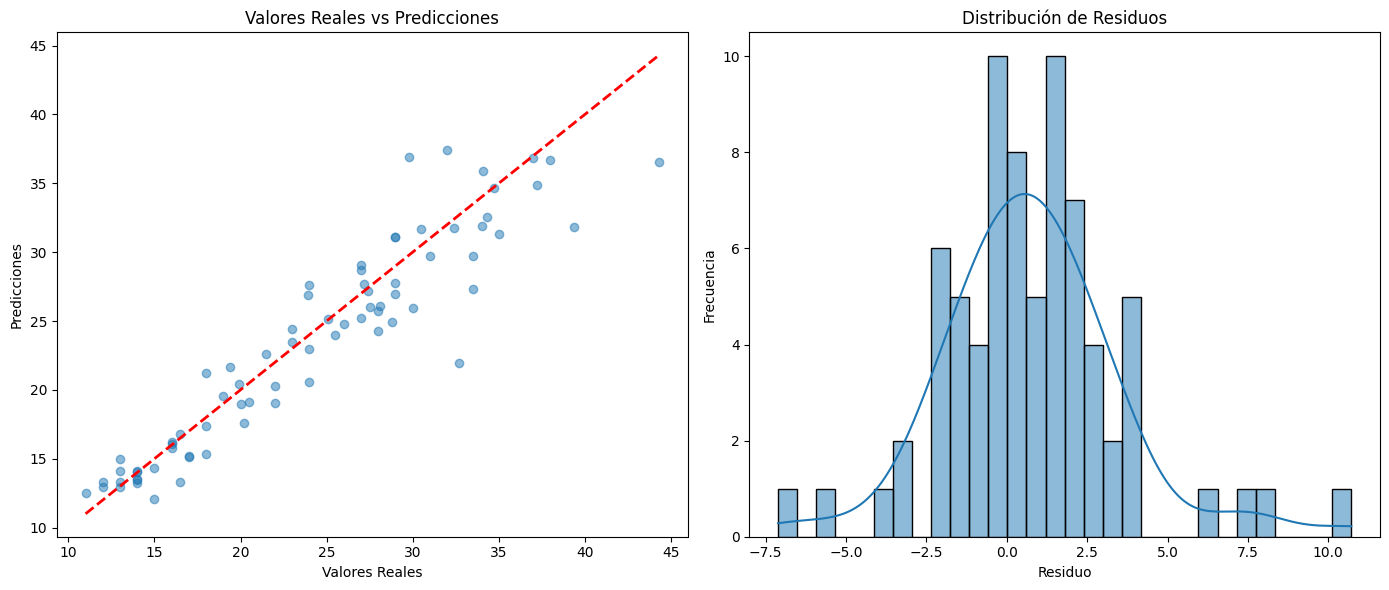

In [ ]:
# Graficar los resultados
plt.figure(figsize=(14, 6))

# Gráfico de dispersión de las predicciones en el conjunto de prueba
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs Predicciones')

# Gráfico de los residuos en el conjunto de prueba
plt.subplot(1, 2, 2)
residuos = y_test - y_pred_test
sns.histplot(residuos, kde=True, bins=30)
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')

plt.tight_layout()
plt.show()

Vemos que el grafico de la izquierda, muestra los valores reales del conjunto prueba comparado con las predicciones del modelo. Se observa una correlacion fuerte que se basa en las buenas metricas de evaluacion repotadas, haciendo que el modelo sea suficientemente predictivo.

En el grafico de la derecha, vemos un grafico de residuos (error entre los valores reales y las predicciones del modelo). Observamos una tentativa de distribucion normal de los residuos, que en principio aseguraría que el modelo viene de una distribucion lineal si fuese por completo una campana normal.

Teniendo en cuenta estas observaciones, el modelo lineal o un polinomico de grado bajo se comportan correctamente para inferir valores de *mpg* a partir de las selected features *horsepower* , *weight* , *model year*  y  *car name*. Cumpliendo asi los objetivos pedidos al modelo.
